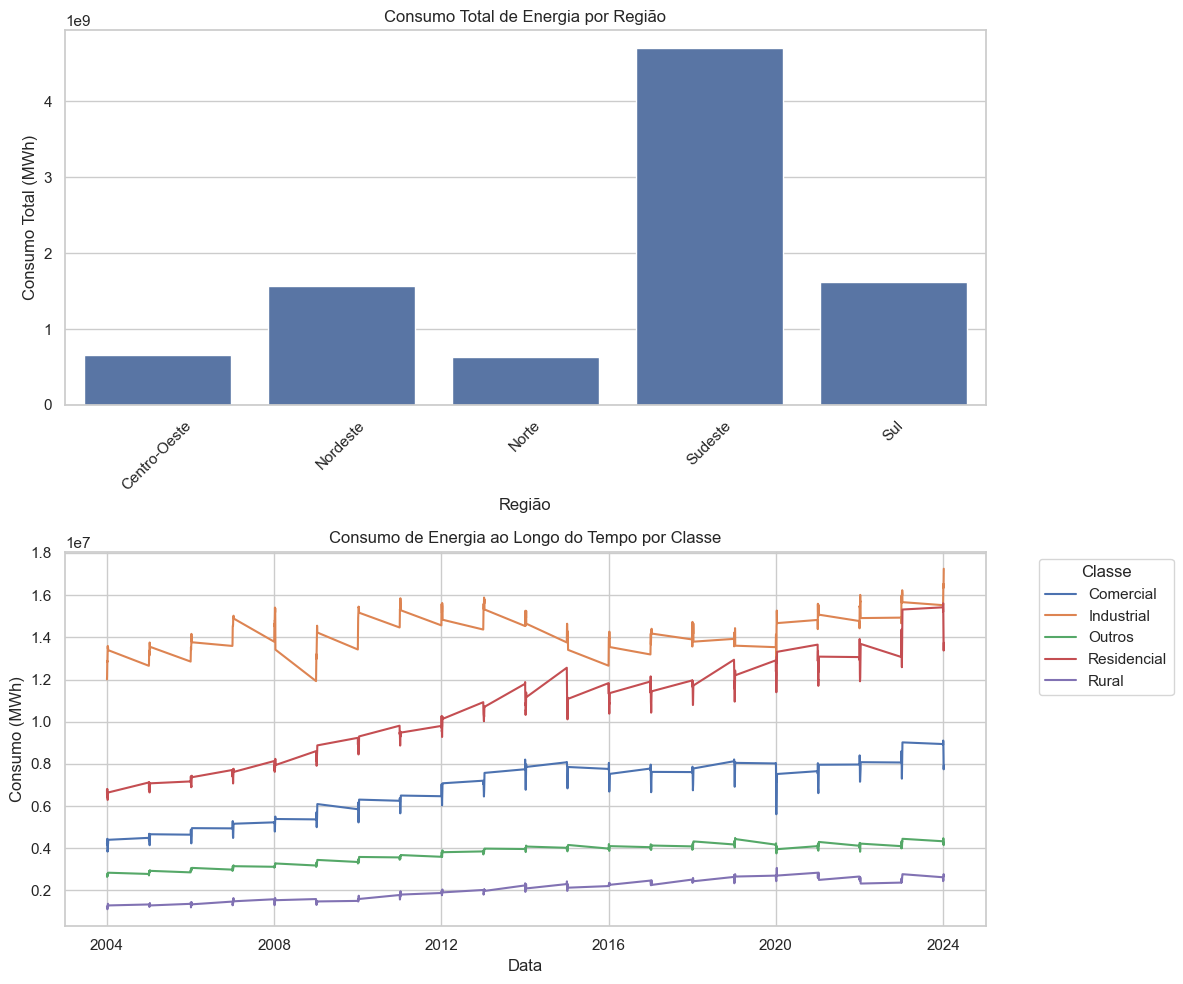

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar os dados
df = pd.read_csv('dados_consumo_energia_mensal_por_regiao.csv')

# Converter a coluna 'data' para o tipo datetime
df['data'] = pd.to_datetime(df['data'])

# Agrupar os dados por região e somar o consumo total
consumo_por_regiao = df.groupby('regiao')['consumo'].sum().reset_index()

# Agrupar os dados por data e classe, somando o consumo
consumo_por_data_classe = df.groupby(['data', 'classe'])['consumo'].sum().reset_index()

# Configurar o estilo dos gráficos
sns.set(style="whitegrid")

# Criar uma figura com dois subgráficos
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico 1: Consumo total por região
sns.barplot(data=consumo_por_regiao, x='regiao', y='consumo', ax=axes[0])
axes[0].set_title('Consumo Total de Energia por Região')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Consumo Total (MWh)')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Consumo ao longo do tempo por classe
sns.lineplot(data=consumo_por_data_classe, x='data', y='consumo', hue='classe', ax=axes[1])
axes[1].set_title('Consumo de Energia ao Longo do Tempo por Classe')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Consumo (MWh)')
axes[1].legend(title='Classe', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar o layout
plt.tight_layout()
plt.show()
